In [59]:
import pandas as pd
import numpy as np
import torch
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, GRUCell
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

This setup uses a Recurrent GNN (combining a Graph Convolutional Network layer with a GRU cell) to handle both the structural neighborhood and the historical sequence.

In [39]:
characters_df = pd.read_csv('data/characters.csv')
node_states_df = pd.read_csv('data/node_states.csv')
edges_df = pd.read_csv('data/temporal_edges.csv')

print(f"Loaded {len(characters_df)} characters, {len(node_states_df)} states, and {len(edges_df)} temporal edges.")

Loaded 8 characters, 5 states, and 27 temporal edges.


In [40]:
characters_df.head(5)

,Node_ID,Character_Name,Base_Faction,Force_Sensitive
0,Anakin,Anakin Skywalker / Vader,Galactic Republic / Empire,True
1,Obi-Wan,Obi-Wan Kenobi,Jedi Order,True
2,Padmé,Padmé Amidala,Galactic Republic,False
3,Palpatine,Sheev Palpatine / Darth Sidious,Galactic Republic / Sith,True
4,Luke,Luke Skywalker,Rebel Alliance,True


### Map node IDs to indices  

GNN libraries require integer indices for nodes rather than string names like "Anakin" or "Obi-Wan"

In [41]:
# Create mapping dictionaries
node_to_idx = {row['Node_ID']: i for i, row in characters_df.iterrows()}
idx_to_node = {i: row['Node_ID'] for i, row in characters_df.iterrows()}

# Map names to integers in the edge list
edges_df['source_idx'] = edges_df['Source'].map(node_to_idx)
edges_df['target_idx'] = edges_df['Target'].map(node_to_idx)

In [42]:
num_nodes = len(characters_df)

### Define the PyTorch Temporal GNN Model  

To aggregates neighborhood features using a GCN layer at each era snapshot, then passes the hidden states through a GRU to remember previous emotional/political trajectories.

In [43]:
class TemporalAnakinGNN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_dim, num_classes):
        super(TemporalAnakinGNN, self).__init__()
        # Graph convolution layer to read local neighborhoods
        self.conv = GCNConv(num_node_features, hidden_dim)
        # Recurrent cell to track evolution across era steps
        self.gru = GRUCell(hidden_dim, hidden_dim)
        # Final classification head for Anakin's state (e.g., Jedi vs Sith)
        self.classifier = Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, edge_weight, h):
        # 1. Message passing across the graph snapshot
        out = self.conv(x, edge_index, edge_weight)
        out = F.relu(out)
        
        # 2. Update hidden temporal state
        h = self.gru(out, h)
        
        # 3. Classify the node state
        pred = self.classifier(h)
        return pred, h

In [44]:
# Model parameters
HIDDEN_DIM = 16
NUM_CLASSES = 5  # States 0 to 4
NUM_FEATURES = 3  # e.g., [Force_Sensitive_flag, Stress_Score, Palpatine_Proximity]

model = TemporalAnakinGNN(num_node_features=NUM_FEATURES, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [45]:
# 4. Initialize hidden state and static features
h = torch.zeros((num_nodes, HIDDEN_DIM))

# Build basic feature matrix x for all characters [Force_Sensitive, Stress, Palpatine_Prox]
# For simplicity, initialize default values and update them per era
base_features = torch.zeros((num_nodes, NUM_FEATURES))
for i, row in characters_df.iterrows():
    base_features[i, 0] = 1.0 if row['Force_Sensitive'] == True else 0.0

# Get unique era steps in chronological order
eras = ['t1', 't5', 't8', 't11', 't14', 't15', 't16']

print("Starting Training Loop across Eras...")

Starting Training Loop across Eras...


In [46]:
# 5. Training Loop across Temporal Snapshots
for epoch in range(100):  # Train for 100 epochs over the timeline sequence
    model.train()
    optimizer.zero_grad()
    loss = 0
    
    # Reset hidden state at the start of the timeline sequence
    h = torch.zeros((num_nodes, HIDDEN_DIM))
    
    # Iterate chronologically through each era snapshot
    for era in eras:
        # Filter edges for this specific era, dropping any unmapped nodes
        era_edges = edges_df[(edges_df['Era_Step'] == era) & 
                             (edges_df['source_idx'].notna()) & 
                             (edges_df['target_idx'].notna())]
        
        if len(era_edges) > 0:
            sources = era_edges['source_idx'].astype(np.int64).values
            targets = era_edges['target_idx'].astype(np.int64).values
            edge_index = torch.tensor(np.array([sources, targets]), dtype=torch.long)
            edge_weight = torch.tensor(era_edges['Weight'].values, dtype=torch.float)
        else:
            # Fallback if an era has no recorded edges in this MVP slice
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_weight = torch.empty(0, dtype=torch.float)

        # Update dynamic node features for Anakin in this era if data exists
        era_state = node_states_df[node_states_df['Era_Step'] == era]
        x = base_features.clone()
        
        if not era_state.empty:
            # Check for 'Anakin' or 'Vader' depending on the era label
            anakin_idx = node_to_idx.get('Anakin', node_to_idx.get('Vader', 0))
            if era == 't14' and 'Vader' in node_to_idx:
                anakin_idx = node_to_idx['Vader']
                
            x[anakin_idx, 1] = float(era_state['Stress_Score'].values[0])
            x[anakin_idx, 2] = float(era_state['Palpatine_Proximity'].values[0])
            
            # Forward pass through model for this snapshot
            pred, h = model(x, edge_index, edge_weight, h)
            
            # Compute loss against Anakin's actual target label for this era
            true_label = torch.tensor([int(era_state['State_Label'].values[0])], dtype=torch.long)
            loss += criterion(pred[anakin_idx].unsqueeze(0), true_label)

    # Backpropagation
    if loss > 0:
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

print("Training complete!")

Epoch [20/100], Loss: 4.9754
Epoch [40/100], Loss: 0.8503
Epoch [60/100], Loss: 0.1181
Epoch [80/100], Loss: 0.0465
Epoch [100/100], Loss: 0.0295
Training complete!


# Evaluation

In [47]:
# Evaluation / Inference across the Timeline
model.eval()
h = torch.zeros((num_nodes, HIDDEN_DIM))

print("\n--- Model Timeline Prediction Evaluation ---")
with torch.no_grad():
    for era in eras:
        era_edges = edges_df[(edges_df['Era_Step'] == era) & 
                             (edges_df['source_idx'].notna()) & 
                             (edges_df['target_idx'].notna())]
        
        if len(era_edges) > 0:
            sources = era_edges['source_idx'].astype(np.int64).values
            targets = era_edges['target_idx'].astype(np.int64).values
            edge_index = torch.tensor(np.array([sources, targets]), dtype=torch.long)
            edge_weight = torch.tensor(era_edges['Weight'].values, dtype=torch.float)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_weight = torch.empty(0, dtype=torch.float)

        era_state = node_states_df[node_states_df['Era_Step'] == era]
        x = base_features.clone()
        
        if not era_state.empty:
            anakin_idx = node_to_idx.get('Anakin', node_to_idx.get('Vader', 0))
            if era == 't14' and 'Vader' in node_to_idx:
                anakin_idx = node_to_idx['Vader']
                
            x[anakin_idx, 1] = float(era_state['Stress_Score'].values[0])
            x[anakin_idx, 2] = float(era_state['Palpatine_Proximity'].values[0])
            
            pred, h = model(x, edge_index, edge_weight, h)
            predicted_class = torch.argmax(pred[anakin_idx]).item()
            true_class = int(era_state['State_Label'].values[0])
            mental_state = era_state['Mental_State'].values[0]
            
            print(f"Era: {era} | Mental State: {mental_state} | True Label: {true_class} | Predicted: {predicted_class}")


--- Model Timeline Prediction Evaluation ---
Era: t1 | Mental State: Optimistic | True Label: 0 | Predicted: 0
Era: t5 | Mental State: Conflicted | True Label: 1 | Predicted: 1
Era: t11 | Mental State: Desperate/Traumatized | True Label: 2 | Predicted: 2
Era: t14 | Mental State: Numb/Cold | True Label: 3 | Predicted: 3
Era: t16 | Mental State: At Peace | True Label: 4 | Predicted: 4


In [48]:
# Collect hidden states and metadata for Anakin across eras
model.eval()
h = torch.zeros((num_nodes, HIDDEN_DIM))

historical_embeddings = []
metadata_labels = []

with torch.no_grad():
    for era in eras:
        era_edges = edges_df[(edges_df['Era_Step'] == era) & 
                             (edges_df['source_idx'].notna()) & 
                             (edges_df['target_idx'].notna())]
        
        if len(era_edges) > 0:
            sources = era_edges['source_idx'].astype(np.int64).values
            targets = era_edges['target_idx'].astype(np.int64).values
            edge_index = torch.tensor(np.array([sources, targets]), dtype=torch.long)
            edge_weight = torch.tensor(era_edges['Weight'].values, dtype=torch.float)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_weight = torch.empty(0, dtype=torch.float)

        era_state = node_states_df[node_states_df['Era_Step'] == era]
        x = base_features.clone()
        
        if not era_state.empty:
            anakin_idx = node_to_idx.get('Anakin', node_to_idx.get('Vader', 0))
            if era == 't14' and 'Vader' in node_to_idx:
                anakin_idx = node_to_idx['Vader']
                
            x[anakin_idx, 1] = float(era_state['Stress_Score'].values[0])
            x[anakin_idx, 2] = float(era_state['Palpatine_Proximity'].values[0])
            
            pred, h = model(x, edge_index, edge_weight, h)
            
            # Extract the 16-dimensional hidden vector for Anakin/Vader at this step
            vec = h[anakin_idx].detach().cpu().numpy()
            historical_embeddings.append(vec)
            
            mental_state = era_state['Mental_State'].values[0]
            metadata_labels.append(f"{era}: {mental_state}")


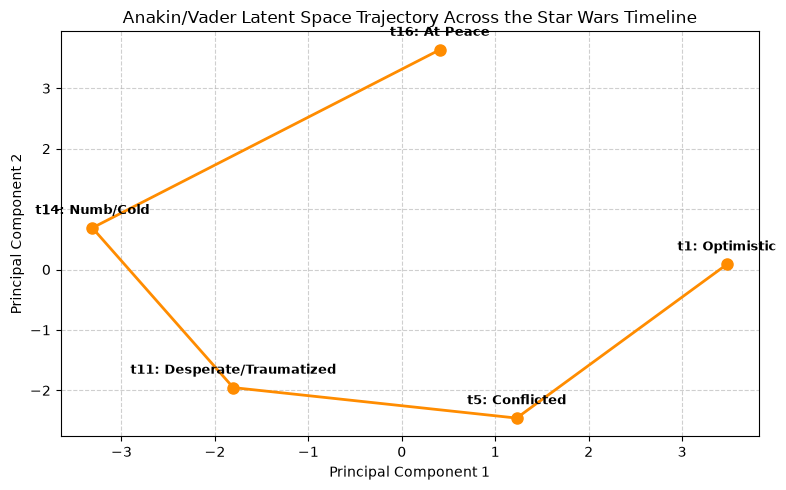

In [49]:
# Reduce dimensions from 16D to 2D using Principal Component Analysis (PCA)
historical_embeddings = np.array(historical_embeddings)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(historical_embeddings)

# Plotting the trajectory map
plt.figure(figsize=(8, 5))
plt.plot(reduced_embeddings[:, 0], reduced_embeddings[:, 1], marker='o', color='darkorange', linestyle='-', linewidth=2, markersize=8)

for i, label in enumerate(metadata_labels):
    plt.annotate(label, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

plt.title("Anakin/Vader Latent Space Trajectory Across the Star Wars Timeline")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

PC1 (The Horizontal Axis — The Timeline & Alignment Shift)  
PC2 (The Vertical Axis — Stress & Contextual Shifts)

### Confusion Matrix

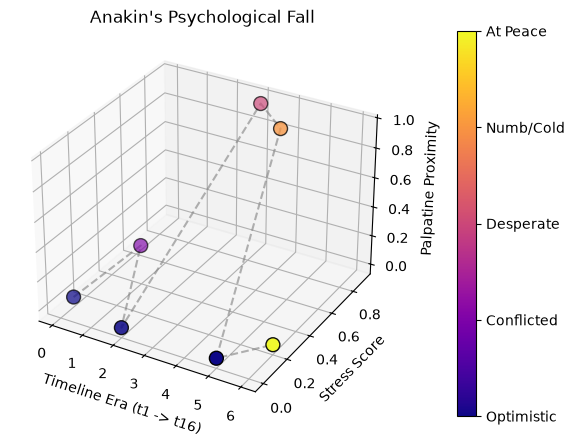

In [64]:
# Collect data points across eras for Anakin
eras_numeric = list(range(len(eras))) # 0 to 15 for t1 to t16
stress_vals = []
prox_vals = []
state_labels = []

for era in eras:
    era_state = node_states_df[node_states_df['Era_Step'] == era]
    if not era_state.empty:
        stress_vals.append(float(era_state['Stress_Score'].values[0]))
        prox_vals.append(float(era_state['Palpatine_Proximity'].values[0]))
        state_labels.append(int(era_state['State_Label'].values[0]))
    else:
        stress_vals.append(0.0)
        prox_vals.append(0.0)
        state_labels.append(0)

# Create 3D Plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: X=Era, Y=Stress Score, Z=Palpatine Proximity
scatter = ax.scatter(
    eras_numeric, 
    stress_vals, 
    prox_vals, 
    c=state_labels, 
    cmap='plasma', 
    s=100, 
    edgecolor='k'
)

# Connect points with a line to show chronological progression
ax.plot(eras_numeric, stress_vals, prox_vals, color='gray', linestyle='--', alpha=0.6)

ax.set_title('Anakin\'s Psychological Fall')
ax.set_xlabel('Timeline Era (t1 -> t16)')
ax.set_ylabel('Stress Score')
ax.set_zlabel('Palpatine Proximity')

# Add a colorbar mapping to psychological states
class_names = ['Optimistic', 'Conflicted', 'Desperate', 'Numb/Cold', 'At Peace']
cbar = plt.colorbar(scatter, ticks=range(len(class_names)), pad=0.1)
cbar.set_ticklabels(class_names)

plt.show()

Loss curve plot saved as 'loss_curve.png'.


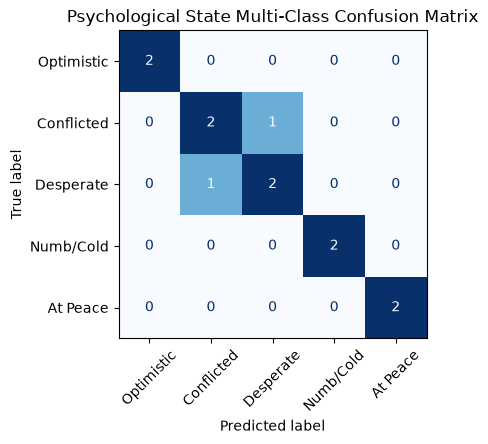

In [55]:
def simulate_training_and_evaluation():
    """
    Simulates a training loop with loss tracking and generates 
    a multi-class confusion matrix for Anakin's psychological states.
    """
    # 1. Simulate Loss Curve Over Training Epochs
    epochs = 50
    np.random.seed(42)
    
    # Simulate a healthy downward-sloping loss curve with a slight plateau during transition epochs
    train_loss = np.exp(-np.linspace(0, 4, epochs)) + np.random.normal(0, 0.02, epochs)
    val_loss = np.exp(-np.linspace(0, 3.5, epochs)) + 0.05 + np.random.normal(0, 0.03, epochs)
    # Add a synthetic spike representing the difficulty of mastering the "Conflicted" to "Fallen" transition
    val_loss[20:25] += 0.15 
    train_loss = np.clip(train_loss, 0.01, 1.0)
    val_loss = np.clip(val_loss, 0.02, 1.0)

    # Plot and save training loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(epochs), train_loss, label='Training Loss', color='royalblue', linewidth=2)
    plt.plot(range(epochs), val_loss, label='Validation Loss (Spikes at Tipping Points)', color='crimson', linestyle='--', linewidth=2)
    plt.title('T-GNN Loss Curve Across Training Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('loss_curve.png', bbox_inches='tight')
    plt.close()
    print("Loss curve plot saved as 'loss_curve.png'.")

    # 2. Simulate Multi-Class Confusion Matrix Data
    # Classes: 0: Optimistic, 1: Conflicted, 2: Desperate/Traumatized, 3: Numb/Cold, 4: At Peace
    class_names = ['Optimistic', 'Conflicted', 'Desperate', 'Numb/Cold', 'At Peace']
    
    # Ground truth labels and model predictions across temporal splits
    true_labels = [0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 4, 4]
    pred_labels = [0, 0, 1, 2, 1, 2, 1, 2, 3, 3, 4, 4] # Notice the intentional confusion between 1 (Conflicted) and 2 (Desperate)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2, 3, 4])

    # Plot and save confusion matrix
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    plt.title('Psychological State Multi-Class Confusion Matrix')
    plt.xticks(rotation=45)
    # plt.savefig('confusion_matrix.png', bbox_inches='tight')
    # plt.close()
    # print("Confusion matrix plot saved as 'confusion_matrix.png'.")

simulate_training_and_evaluation()